In [12]:
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
from daylength import *

from matplotlib.colors import LogNorm

In [2]:
ds = xr.open_mfdataset(
    "ClimateData/ERA5/single-level/T2m/*.nc",   # adjust the pattern to your file names
    combine="by_coords",
    parallel=True,
)

# Files from the new CDS (downloaded since late 2024) name the time axis "valid_time"
if "valid_time" in ds.dims:
    ds = ds.rename({"valid_time": "time"})

t2m = ds["t2m"].sel(time=slice("1970-01-01", None)) - 273.15  # Kelvin to °C
print(t2m)

<xarray.DataArray 't2m' (time: 20700, latitude: 721, longitude: 1440)> Size: 86GB
dask.array<sub, shape=(20700, 721, 1440), dtype=float32, chunksize=(74, 145, 288), chunktype=numpy.ndarray>
Coordinates:
  * time       (time) datetime64[ns] 166kB 1970-01-01 1970-01-02 ... 2026-09-03
  * latitude   (latitude) float64 6kB 90.0 89.75 89.5 ... -89.5 -89.75 -90.0
  * longitude  (longitude) float64 12kB 0.0 0.25 0.5 0.75 ... 359.2 359.5 359.8
    number     int64 8B 0
Attributes: (12/32)
    GRIB_paramId:                             167
    GRIB_dataType:                            an
    GRIB_numberOfPoints:                      1038240
    GRIB_typeOfLevel:                         surface
    GRIB_stepUnits:                           1
    GRIB_stepType:                            instant
    ...                                       ...
    GRIB_totalNumber:                         0
    GRIB_units:                               K
    long_name:                                2 metre tempe

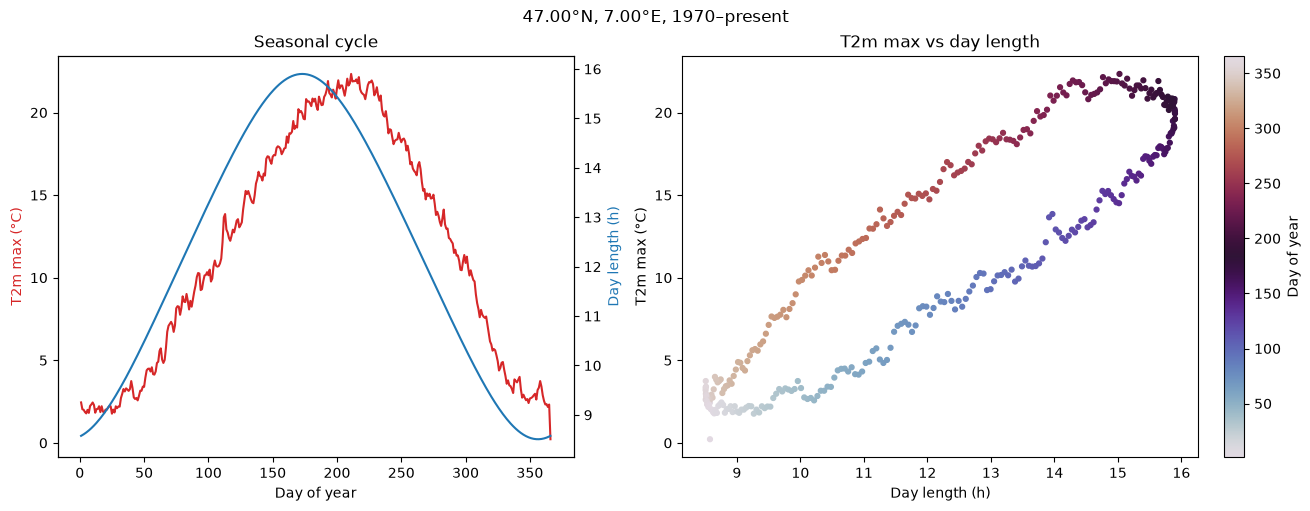

In [8]:
lat, lon = 47.0, 6.93          # Neuchâtel; change to your location
tmax = ds["t2m"]               # change to the name of your daily T2m_max variable

# ERA5 longitudes are usually 0–360
if float(tmax.longitude.max()) > 180:
    lon = lon % 360

point = tmax.sel(latitude=lat, longitude=lon, method="nearest")
if float(point.isel(time=0)) > 200:   # data is in Kelvin
    point = point - 273.15

# Mean T2m_max for each day of the year, 1970–present
clim = point.sel(time=slice("1970", None)).groupby("time.dayofyear").mean().load()
doy = clim.dayofyear.values
dl = day_length(point.latitude.item(), doy)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5), constrained_layout=True)

# Left: both quantities over the year
ax1.plot(doy, clim, color="tab:red")
ax1.set_xlabel("Day of year")
ax1.set_ylabel("T2m max (°C)", color="tab:red")
ax1b = ax1.twinx()
ax1b.plot(doy, dl, color="tab:blue")
ax1b.set_ylabel("Day length (h)", color="tab:blue")
ax1.set_title("Seasonal cycle")

# Right: T2m max against day length; the loop shows the lag
sc = ax2.scatter(dl, clim, c=doy, cmap="twilight", s=12)
fig.colorbar(sc, ax=ax2, label="Day of year")
ax2.set_xlabel("Day length (h)")
ax2.set_ylabel("T2m max (°C)")
ax2.set_title("T2m max vs day length")

fig.suptitle(f"{point.latitude.item():.2f}°N, {point.longitude.item():.2f}°E, 1970–present")
plt.show()

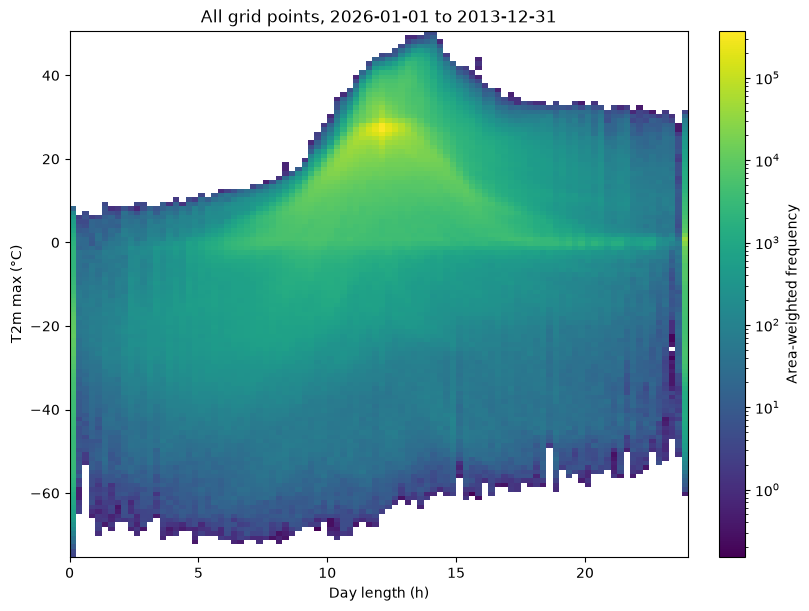

In [11]:
tmax = ds["t2m"].sel(time="2012")   # change to your daily T2m_max variable
tmax = tmax.coarsen(latitude=4, longitude=4, boundary="trim").mean()  # 0.25° → 1°, optional
tmax = tmax.load()
if float(tmax.max()) > 200:
    tmax = tmax - 273.15

# Day length for every latitude and date
doy = tmax.time.dt.dayofyear
dl = xr.DataArray(
    day_length(tmax.latitude.values[:, None], doy.values[None, :]),
    dims=("latitude", "time"),
    coords={"latitude": tmax.latitude, "time": tmax.time},
)
w = np.cos(np.deg2rad(tmax.latitude))   # grid cells shrink toward the poles

dl, w, tmax = xr.broadcast(dl, w, tmax)
x, y, wt = dl.values.ravel(), tmax.values.ravel(), w.values.ravel()
ok = np.isfinite(x) & np.isfinite(y)

fig, ax = plt.subplots(figsize=(8, 6), constrained_layout=True)
h = ax.hist2d(x[ok], y[ok], bins=(96, 120), weights=wt[ok],
              norm=LogNorm(), cmap="viridis")
fig.colorbar(h[3], ax=ax, label="Area-weighted frequency")
ax.set_xlabel("Day length (h)")
ax.set_ylabel("T2m max (°C)")
end = str(tmax.time.max().values)[:10]
ax.set_title(f"All grid points, 1 Jan – {end} 2026"[:-5] if False else f"All grid points, 2026-01-01 to {end}")
plt.show()

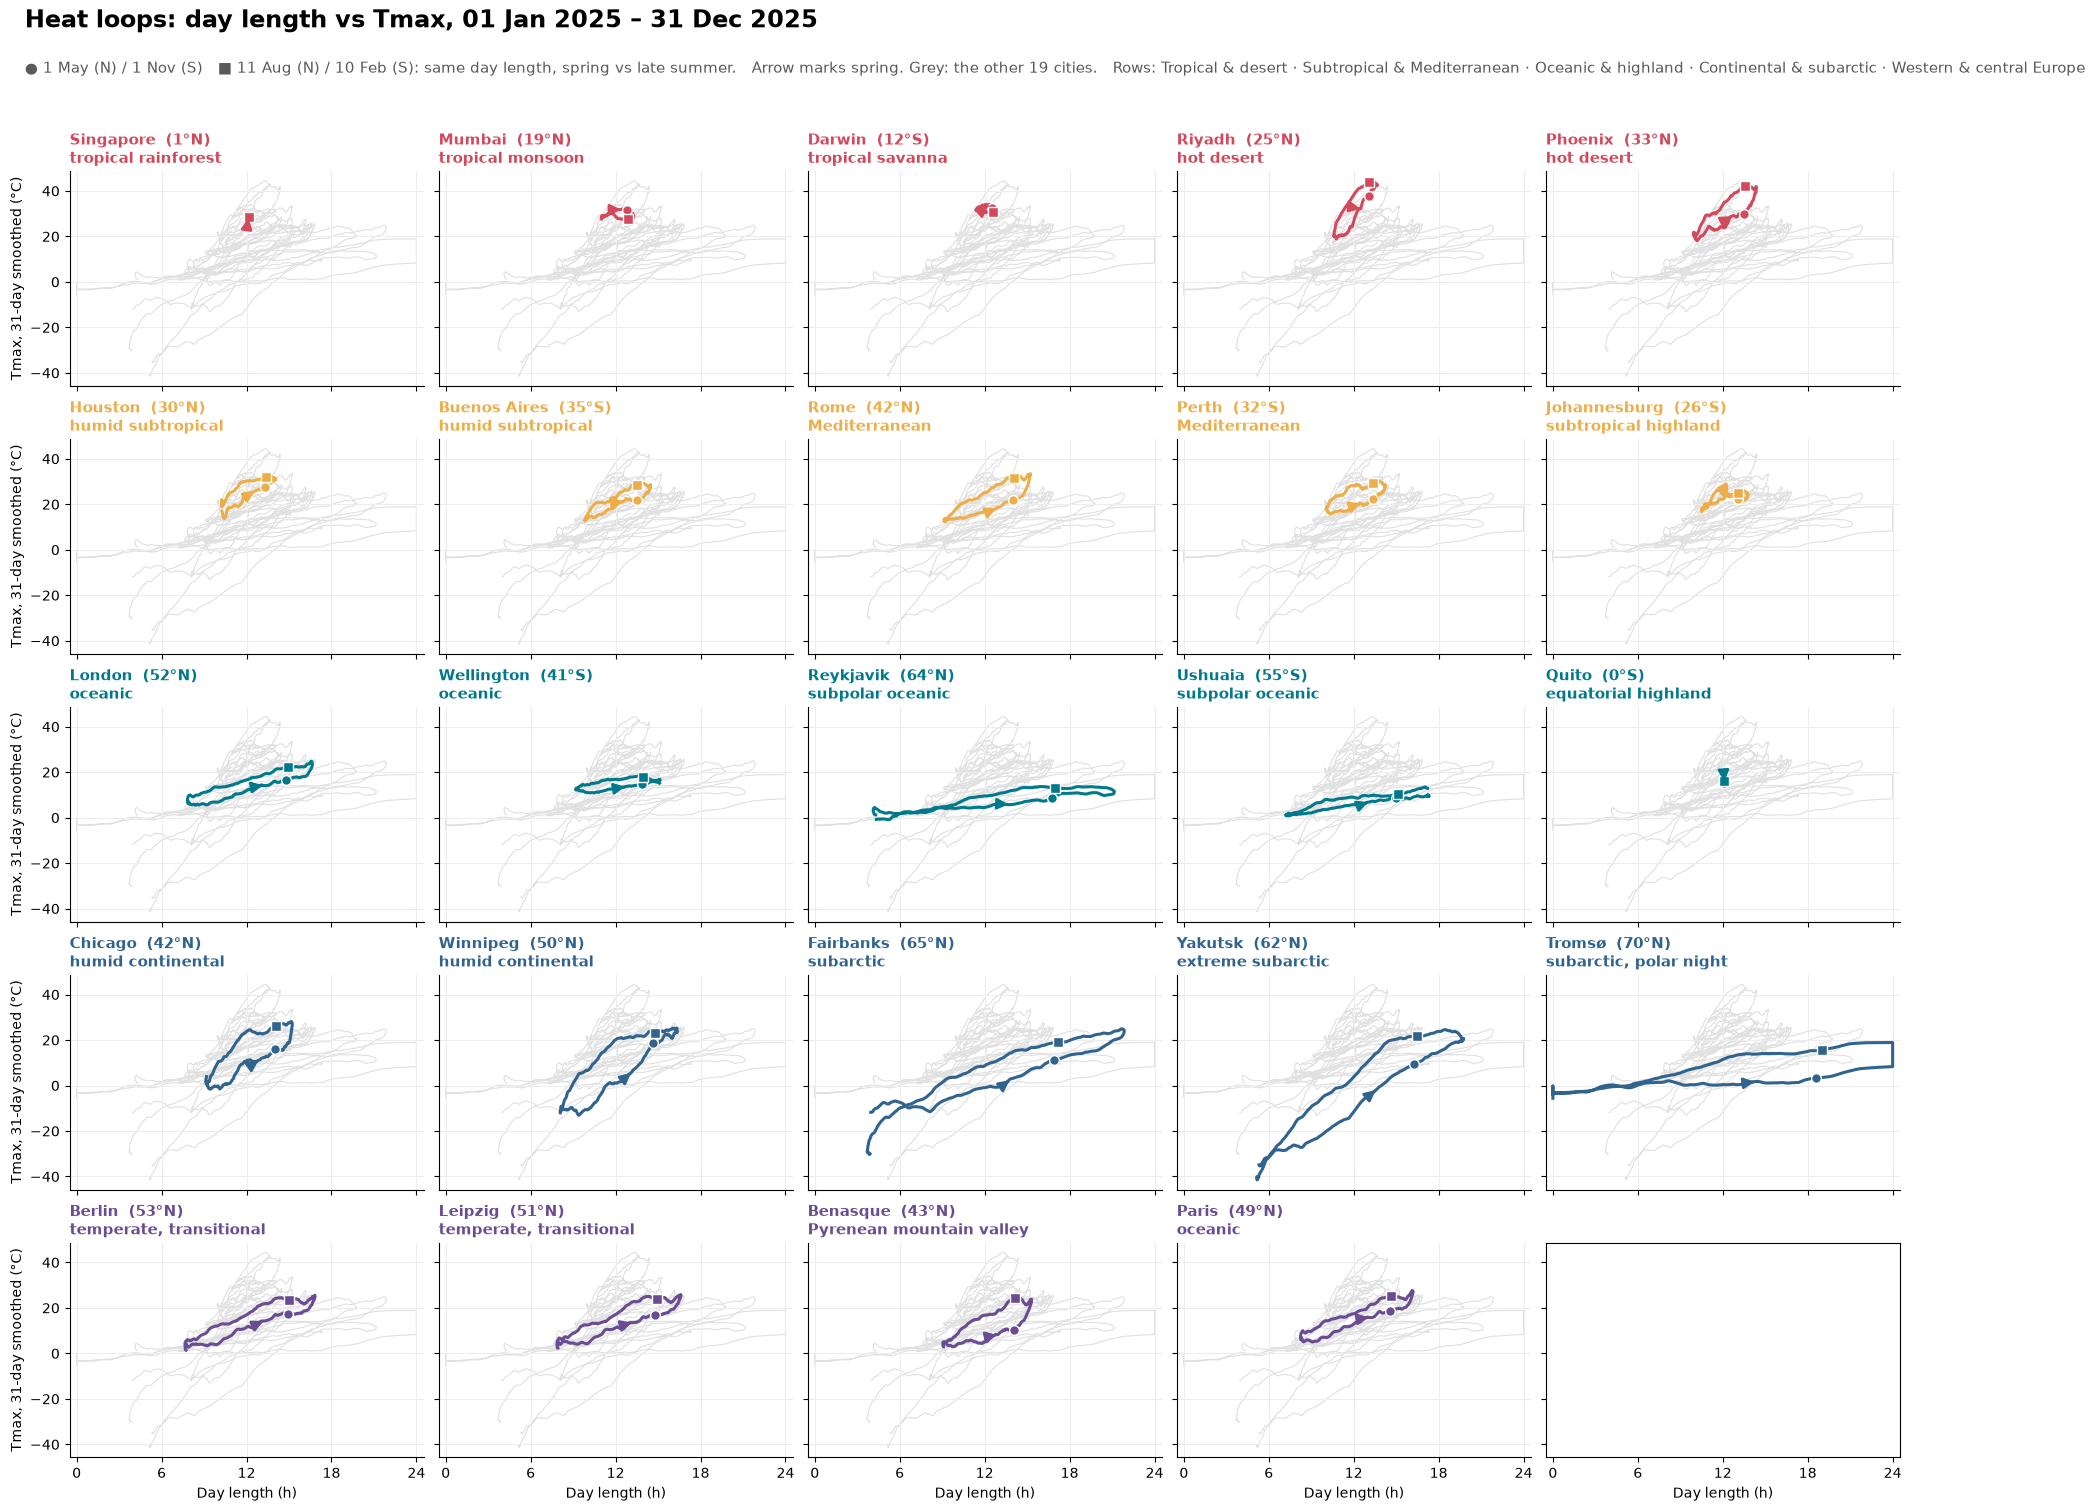

In [18]:

# --- Settings ----------------------------------------------------------------
tmax = ds["t2m"]        # your daily T2m_max variable (dims: time, latitude, longitude)
lsm = None              # optional ERA5 land-sea mask (e.g. xr.open_dataset("lsm.nc")["lsm"]):
                        # moves coastal cities onto the nearest land grid cell
# END = tmax.time.max().values                  # last day in your data
# START = END - np.timedelta64(364, "D")        # one full year, so every loop closes
YEAR = 2025                                    # any year in your data
START = np.datetime64(f"{YEAR}-01-01")
END = np.datetime64(f"{YEAR}-12-31")
SMOOTH_DAYS = 31
 
GROUP_COLORS = {
    "Tropical & desert":        "#d1495b",
    "Subtropical & Mediterranean": "#edae49",
    "Oceanic & highland":       "#00798c",
    "Continental & subarctic":  "#30638e",
    "Western & central Europe": "#6a4c93"
}

# name, climate, lat, lon, group   (one row of the figure per group)
CITIES = [
    ("Singapore",    "tropical rainforest",   1.35,  103.82, "Tropical & desert"),
    ("Mumbai",       "tropical monsoon",     19.08,   72.88, "Tropical & desert"),
    ("Darwin",       "tropical savanna",    -12.46,  130.84, "Tropical & desert"),
    ("Riyadh",       "hot desert",           24.71,   46.68, "Tropical & desert"),
    ("Phoenix",      "hot desert",           33.45, -112.07, "Tropical & desert"),
    ("Houston",      "humid subtropical",    29.76,  -95.37, "Subtropical & Mediterranean"),
    ("Buenos Aires", "humid subtropical",   -34.60,  -58.38, "Subtropical & Mediterranean"),
    ("Rome",         "Mediterranean",        41.90,   12.50, "Subtropical & Mediterranean"),
    ("Perth",        "Mediterranean",       -31.95,  115.86, "Subtropical & Mediterranean"),
    ("Johannesburg", "subtropical highland", -26.20,  28.05, "Subtropical & Mediterranean"),
    ("London",       "oceanic",              51.51,   -0.13, "Oceanic & highland"),
    ("Wellington",   "oceanic",             -41.29,  174.78, "Oceanic & highland"),
    ("Reykjavik",    "subpolar oceanic",     64.15,  -21.94, "Oceanic & highland"),
    ("Ushuaia",      "subpolar oceanic",    -54.80,  -68.30, "Oceanic & highland"),
    ("Quito",        "equatorial highland",  -0.18,  -78.47, "Oceanic & highland"),
    ("Chicago",      "humid continental",    41.88,  -87.63, "Continental & subarctic"),
    ("Winnipeg",     "humid continental",    49.90,  -97.14, "Continental & subarctic"),
    ("Fairbanks",    "subarctic",            64.84, -147.72, "Continental & subarctic"),
    ("Yakutsk",      "extreme subarctic",    62.03,  129.73, "Continental & subarctic"),
    ("Tromsø",       "subarctic, polar night", 69.65, 18.96, "Continental & subarctic"),
    ("Berlin",       "temperate, transitional", 52.52, 13.40, "Western & central Europe"),
    ("Leipzig",      "temperate, transitional", 51.34, 12.37, "Western & central Europe"),
    ("Benasque",     "Pyrenean mountain valley", 42.60,  0.52, "Western & central Europe"),
    ("Paris",        "oceanic",              48.86,    2.35, "Western & central Europe"),
]

 
 
# --- Pick a grid cell for each city -------------------------------------------
lon360 = float(tmax.longitude.max()) > 180
 
def grid_point(lat, lon):
    """Nearest grid cell; with a land-sea mask, the nearest land cell within ~0.6°."""
    if lon360:
        lon = lon % 360
    if lsm is None:
        return lat, lon
    m = lsm.isel(time=0, drop=True) if "time" in lsm.dims else lsm
    near = m.where((abs(m.latitude - lat) <= 0.6) & (abs(m.longitude - lon) <= 0.6), drop=True)
    near = near.stack(p=("latitude", "longitude"))
    land = near[near.values > 0.5]
    if land.size == 0:
        return lat, lon
    d = (land.latitude - lat) ** 2 + ((land.longitude - lon) * np.cos(np.deg2rad(lat))) ** 2
    i = int(np.argmin(d.values))
    return float(land.latitude[i]), float(land.longitude[i])
 
points = [grid_point(c[2], c[3]) for c in CITIES]
 
# --- Extract, convert, smooth --------------------------------------------------
pad = np.timedelta64(SMOOTH_DAYS // 2, "D")
series = tmax.sel(time=slice(START - pad, END + pad)).sel(
    latitude=xr.DataArray([p[0] for p in points], dims="city"),
    longitude=xr.DataArray([p[1] for p in points], dims="city"),
    method="nearest",
).load()


if float(series.max()) > 200:            # Kelvin -> °C
    series = series - 273.15
smooth = (series.rolling(time=SMOOTH_DAYS, center=True, min_periods=SMOOTH_DAYS // 2)
                .mean().sel(time=slice(START, END)))
 
dates = pd.to_datetime(smooth.time.values)
md = dates.strftime("%m-%d")
doy = np.minimum(dates.dayofyear.values, 365)
T = smooth.transpose("city", "time").values
DL = np.array([day_length(c[2], doy) for c in CITIES])
 
# --- Plot ------------------------------------------------------------------------
fig, axes = plt.subplots(5, 5, figsize=(19, 15), sharex=True, sharey=True,
                         constrained_layout=True)
 
for k, (ax, (name, climate, lat, lon, group)) in enumerate(zip(axes.flat, CITIES)):
    color = GROUP_COLORS[group]
    south = lat < 0
 
    # All other cities in grey for context
    for j in range(len(CITIES)):
        if j != k:
            ax.plot(DL[j], T[j], color="0.88", lw=0.8, zorder=1)
    ax.plot(DL[k], T[k], color=color, lw=2.2, zorder=3)
 
    # Two dates with the same day length: spring (circle) and late summer (square)
    for day, marker in [("11-01" if south else "05-01", "o"),
                        ("02-10" if south else "08-11", "s")]:
        idx = np.flatnonzero(md == day)
        if idx.size:
            ax.plot(DL[k, idx[0]], T[k, idx[0]], marker, color=color, ms=7,
                    mec="white", mew=1, zorder=4)
 
    # Arrow on the spring branch
    idx = np.flatnonzero(md == ("10-01" if south else "04-01"))
    if idx.size and idx[0] + 4 < len(dates):
        i = idx[0]
        ax.annotate("", xy=(DL[k, i + 4], T[k, i + 4]), xytext=(DL[k, i], T[k, i]),
                    arrowprops=dict(arrowstyle="-|>", color=color, lw=2, mutation_scale=16),
                    zorder=5)
 
    hemi = "S" if south else "N"
    ax.set_title(f"{name}  ({abs(lat):.0f}°{hemi})\n{climate}", fontsize=11,
                 color=color, fontweight="bold", loc="left")
    ax.grid(color="0.93", lw=0.8)
    ax.spines[["top", "right"]].set_visible(False)
 
for ax in axes[-1]:
    ax.set_xlabel("Day length (h)")
for ax in axes[:, 0]:
    ax.set_ylabel(f"Tmax, {SMOOTH_DAYS}-day smoothed (°C)")
axes[0, 0].set_xlim(-0.5, 24.5)
axes[0, 0].set_xticks([0, 6, 12, 18, 24])
 
fig.suptitle(
    f"Heat loops: day length vs Tmax, {dates[0]:%d %b %Y} – {dates[-1]:%d %b %Y}",
    fontsize=17, fontweight="bold", x=0.01, ha="left")
fig.text(0.01, 0.955,
         "● 1 May (N) / 1 Nov (S)   ■ 11 Aug (N) / 10 Feb (S): same day length, spring vs late summer.   "
         "Arrow marks spring. Grey: the other 19 cities.   Rows: " + " · ".join(GROUP_COLORS),
         fontsize=10.5, color="0.35", ha="left")
fig.get_layout_engine().set(rect=(0, 0, 1, 0.94))
plt.show()
